# tVHA Circuit drawings

Script to draw (sub)circuits of tVHA.

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit_nature.second_q.mappers import JordanWignerMapper
from vha_plots import get_electronic_structure_problem

from tvha.fermionic_operator import FermionicOp
from tvha.tvha import VariationalHamiltonianAnsatz, print_hamiltonian


In [3]:
%matplotlib

Using matplotlib backend: agg


In [ ]:
mapper = JordanWignerMapper()
problem = get_electronic_structure_problem(molecule_name="H_2", basis_set="sto3g")
vha = VariationalHamiltonianAnsatz(
    problem=problem, trotter_steps=1, mapper=mapper, threshold_gamma=1
)

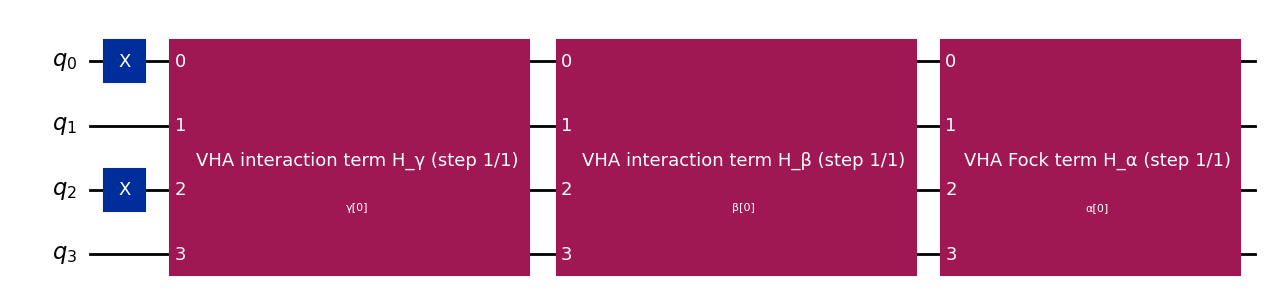

In [5]:
vha.decompose(reps=1).draw("mpl")

In [ ]:
vha.decompose(reps=2).draw("mpl")

In [6]:
print_hamiltonian(vha.hamilton_operator)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## One-body term

<IPython.core.display.Latex object>

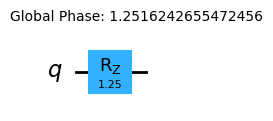

In [7]:
single_one_body_term = "+_0 -_0"
term = FermionicOp({single_one_body_term: vha.hamilton_operator[single_one_body_term]})
print_hamiltonian(term)
operator = PauliEvolutionGate(
    vha.mapper.map(term),
    synthesis=LieTrotter(),
)

circuit = QuantumCircuit(1)
circuit.append(operator, circuit.qubits)
circuit.decompose(reps=1).draw("mpl")

## Coulomb two-body term

<IPython.core.display.Latex object>

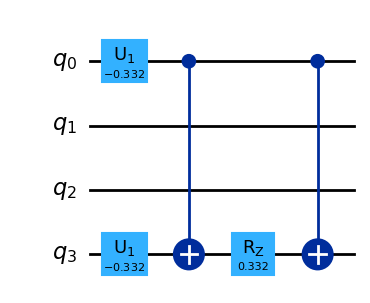

In [8]:
single_coulomb_two_body_term = "+_0 +_3 -_0 -_3"
term = FermionicOp(
    {single_coulomb_two_body_term: vha.hamilton_operator[single_coulomb_two_body_term]}
)
print_hamiltonian(term)
operator = PauliEvolutionGate(
    vha.mapper.map(term),
    synthesis=LieTrotter(),
)

circuit = QuantumCircuit(4)
circuit.append(operator, circuit.qubits)
circuit.decompose(reps=2).draw("mpl")

## Non-Coulomb two-body term
If permutations are left out, the circuit grows significantly. This effect only arises in H_2 due to its high symmetry.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

SparsePauliOp(['YYYY', 'XXYY', 'YYXX', 'XXXX'],
              coeffs=[0.04534167+0.j, 0.04534167+0.j, 0.04534167+0.j, 0.04534167+0.j])


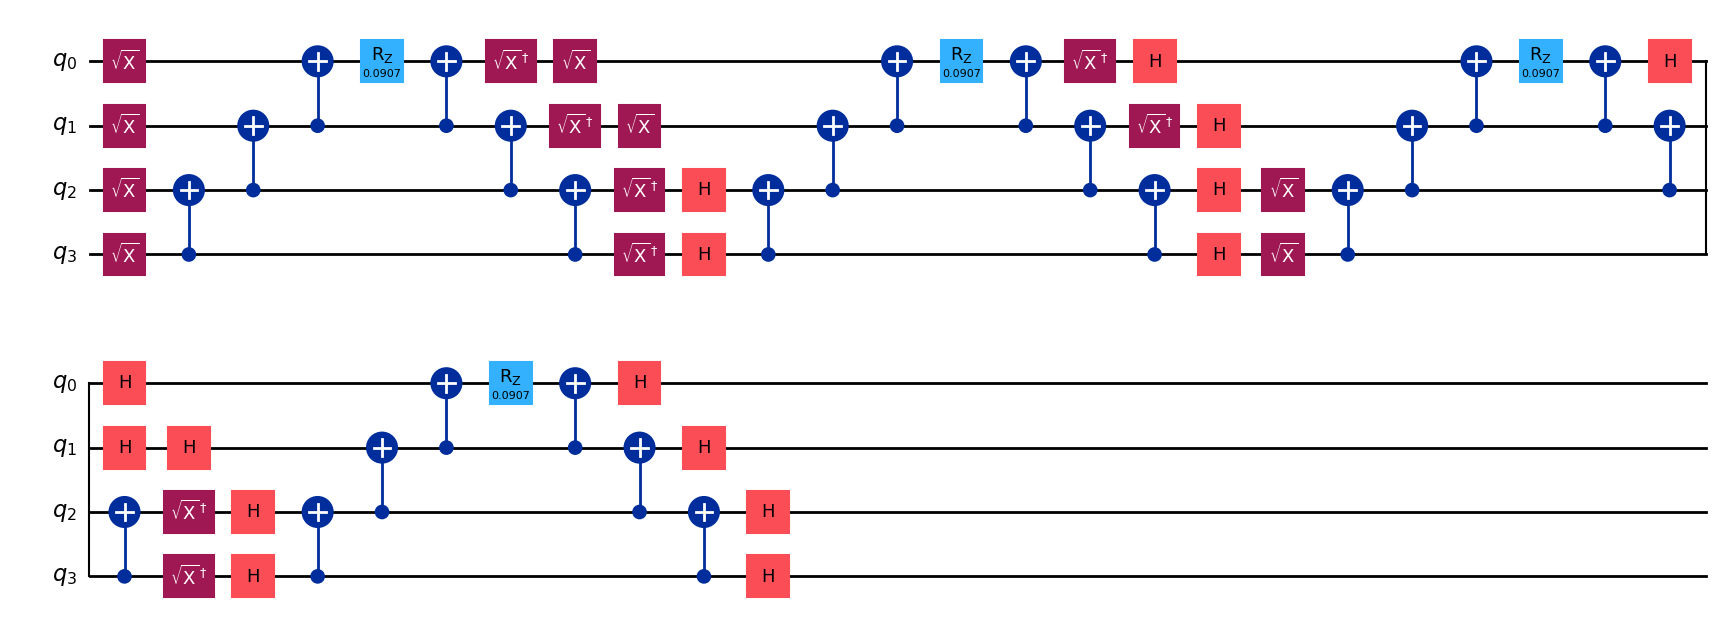

In [9]:
single_non_coulomb_two_body_term_1 = "+_0 +_2 -_1 -_3"
single_non_coulomb_two_body_term_2 = "+_1 +_3 -_0 -_2"
single_non_coulomb_two_body_term_3 = "+_0 +_3 -_1 -_2"
single_non_coulomb_two_body_term_4 = "+_1 +_2 -_0 -_3"
term = FermionicOp(
    {
        single_non_coulomb_two_body_term_1: vha.hamilton_operator[
            single_non_coulomb_two_body_term_1
        ],
        single_non_coulomb_two_body_term_2: vha.hamilton_operator[
            single_non_coulomb_two_body_term_2
        ],
        single_non_coulomb_two_body_term_3: vha.hamilton_operator[
            single_non_coulomb_two_body_term_3
        ],
        single_non_coulomb_two_body_term_4: vha.hamilton_operator[
            single_non_coulomb_two_body_term_4
        ],
    }
)
print_hamiltonian(term)
pauli_operator = vha.mapper.map(term)
print(pauli_operator)
operator = PauliEvolutionGate(
    operator=pauli_operator,
    synthesis=LieTrotter(),
)

circuit = QuantumCircuit(4)
circuit.append(operator, circuit.qubits)
circuit.decompose(reps=1).draw("mpl")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

SparsePauliOp(['XYXY', 'YYYY', 'YXXY', 'XXYY', 'YYXX', 'XYYX', 'XXXX', 'YXYX'],
              coeffs=[-0.02267083+0.j,  0.02267083+0.j,  0.02267083+0.j,  0.02267083+0.j,
  0.02267083+0.j,  0.02267083+0.j,  0.02267083+0.j, -0.02267083+0.j])


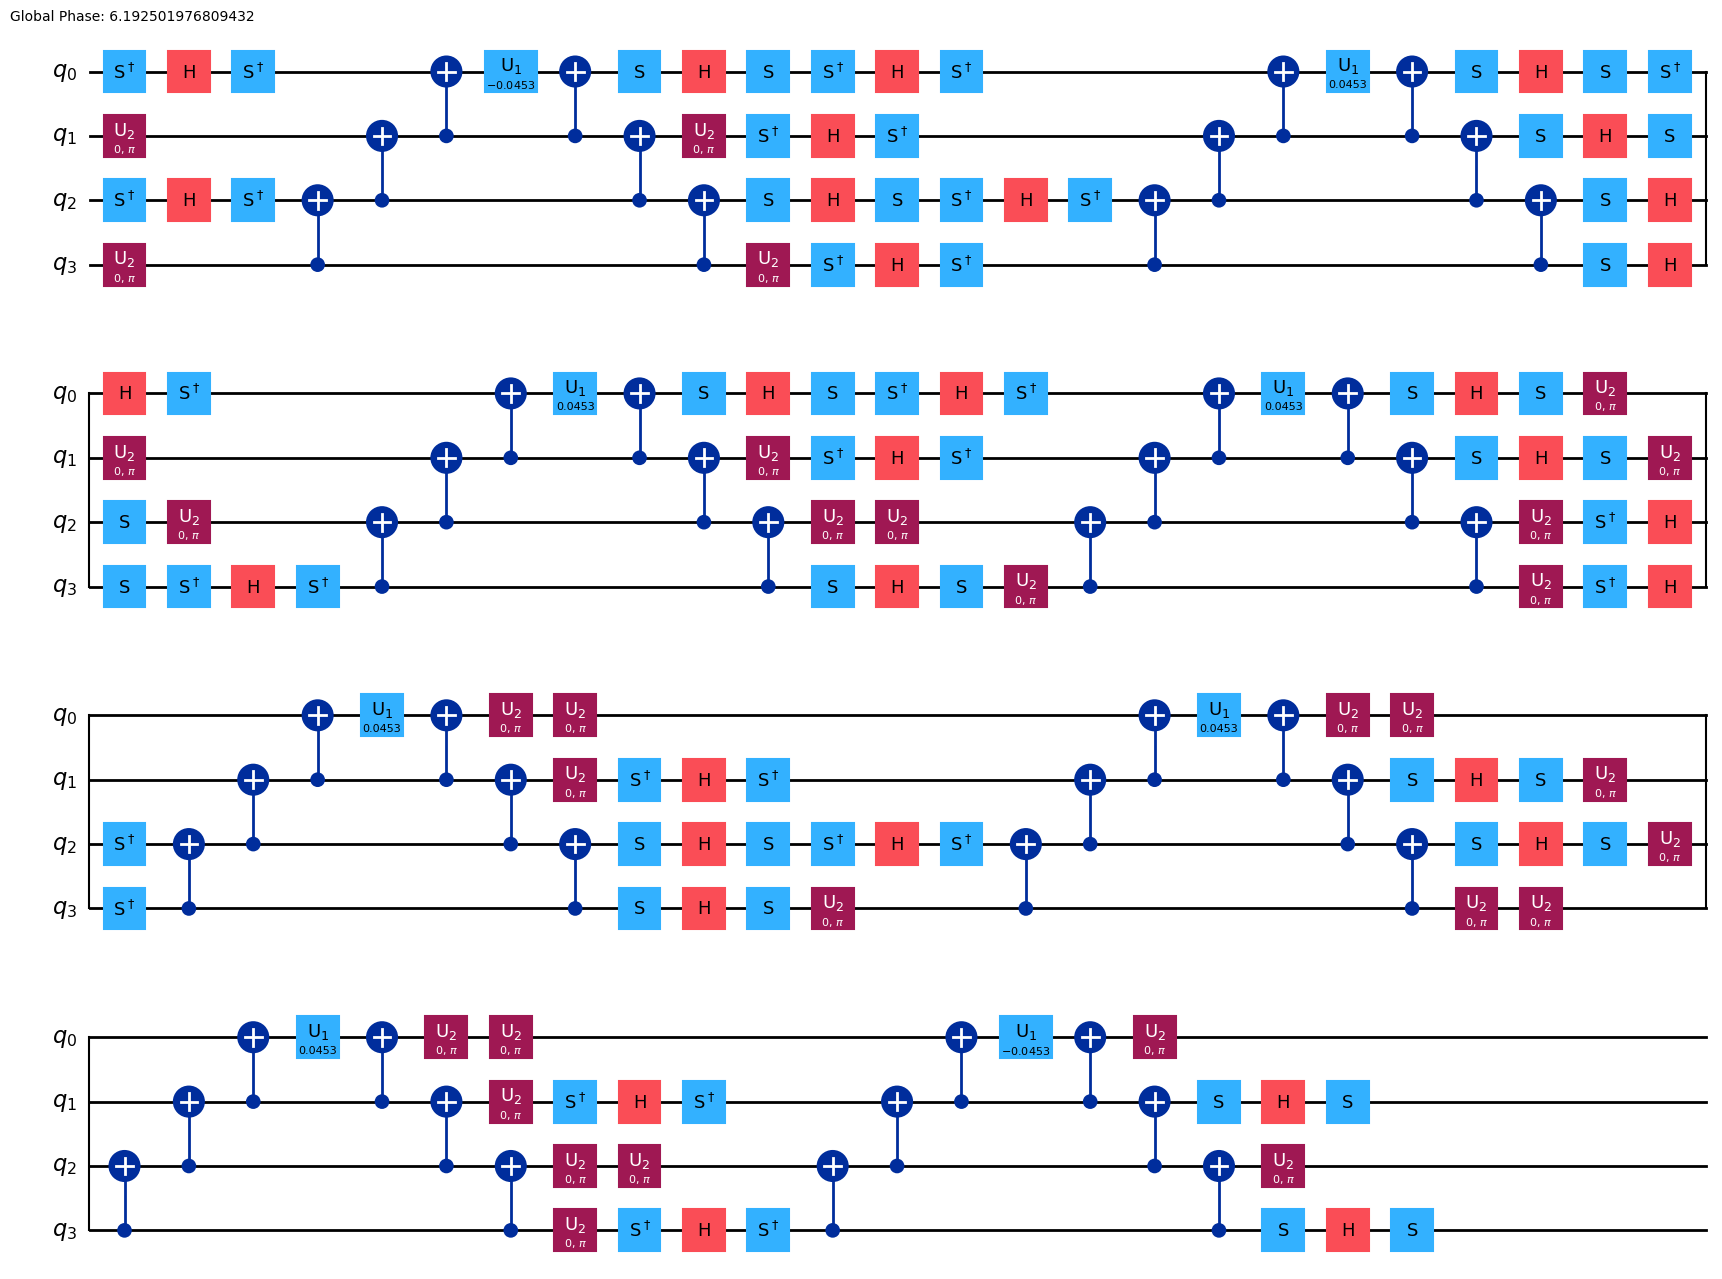

In [10]:
single_non_coulomb_two_body_term_1 = "+_0 +_2 -_1 -_3"
single_non_coulomb_two_body_term_2 = "+_1 +_3 -_0 -_2"
term = FermionicOp(
    {
        single_non_coulomb_two_body_term_1: vha.hamilton_operator[
            single_non_coulomb_two_body_term_1
        ],
        single_non_coulomb_two_body_term_2: vha.hamilton_operator[
            single_non_coulomb_two_body_term_2
        ],
    }
)
print_hamiltonian(term)
pauli_operator = vha.mapper.map(term)
print(pauli_operator)
operator = PauliEvolutionGate(
    operator=pauli_operator,
    synthesis=LieTrotter(),
)

circuit = QuantumCircuit(4)
circuit.append(operator, circuit.qubits)
circuit.decompose(reps=2).draw("mpl")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

SparsePauliOp(['XYXY', 'XXYY', 'YXXY', 'YYYY', 'XXXX', 'XYYX', 'YYXX', 'YXYX'],
              coeffs=[ 0.02267083+0.j,  0.02267083+0.j, -0.02267083+0.j,  0.02267083+0.j,
  0.02267083+0.j, -0.02267083+0.j,  0.02267083+0.j,  0.02267083+0.j])


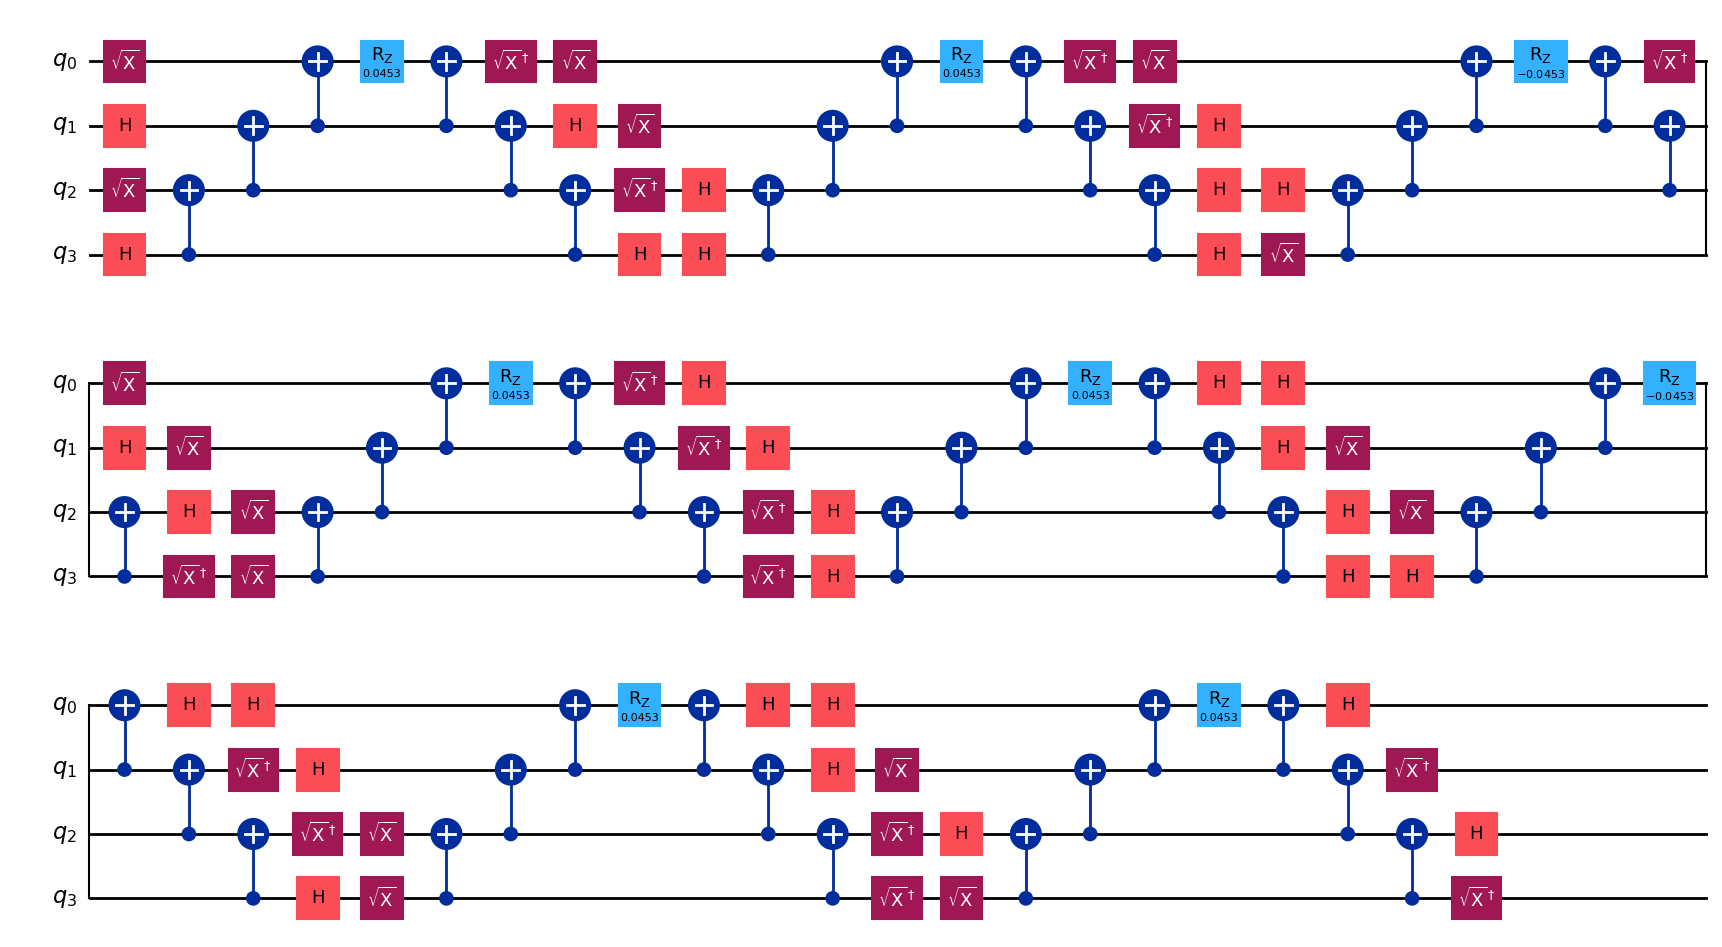

In [11]:
single_non_coulomb_two_body_term_1 = "+_0 +_3 -_1 -_2"
single_non_coulomb_two_body_term_2 = "+_1 +_2 -_0 -_3"
term = FermionicOp(
    {
        single_non_coulomb_two_body_term_1: vha.hamilton_operator[
            single_non_coulomb_two_body_term_1
        ],
        single_non_coulomb_two_body_term_2: vha.hamilton_operator[
            single_non_coulomb_two_body_term_2
        ],
    }
)
print_hamiltonian(term)
pauli_operator = vha.mapper.map(term)
print(pauli_operator)
operator = PauliEvolutionGate(
    operator=pauli_operator,
    synthesis=LieTrotter(),
)

circuit = QuantumCircuit(4)
circuit.append(operator, circuit.qubits)
circuit.decompose(reps=1).draw("mpl")